In [2]:

import pandas as pd
import geemap
import ee
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import json
SHAPEFILE_PATH = "/home/desy/rift-waters/dataset/bounderies/kenya_wards/kenya_wards.shp"



# Or load directly from a public URL (Kenya wards from HDX)
# SHAPEFILE_PATH = "https://data.humdata.org/dataset/..."  

# Ward names to highlight (Baringo lakeshore wards)
LAKESHORE_WARDS = [
    'Kampi ya Samaki',
    'Salabani', 
    'Ilchamus',
    'Ng\'ambo',
    'Mukutani',
    'Marigat'
]

# ============================================
# LOAD AND PROCESS SHAPEFILE
# ============================================

# Read shapefile with geopandas
try:
    gdf = gpd.read_file(SHAPEFILE_PATH)
    print(f"✅ Loaded shapefile with {len(gdf)} features")
    print(f"   CRS: {gdf.crs}")
    print(f"   Columns: {list(gdf.columns)}")
except Exception as e:
    print(f"❌ Error loading shapefile: {e}")
    print("💡 Tip: Make sure the path is correct and all shapefile components exist")
    raise

# Identify the name column (common variations)


g_df = pd.DataFrame(gdf)
g_df.head()
# Convert to GEE-compatible format (WGS84)



✅ Loaded shapefile with 1450 features
   CRS: EPSG:4326
   Columns: ['gid', 'pop2009', 'county', 'subcounty', 'ward', 'uid', 'scuid', 'cuid', 'geometry']


,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry
0,241,17431.0,ISIOLO,Isiolo Sub County,WABERA,rIdiIpv9fBt,I2LYLqKU6AW,bzOfj0iwfDH,"POLYGON ((37.59968 0.40029, 37.59976 0.40004, ..."
1,1455,18755.0,Migori,Rongo Sub County,North Kamagambo Ward,QC41mItjIzF,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.59938 -0.65054, 34.60006 -0.65069..."
2,1456,27756.0,Migori,Rongo Sub County,Central Kamagambo Ward,M8rGveWTIMm,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.61175 -0.73357, 34.61183 -0.73357..."
3,1457,27179.0,Migori,Rongo Sub County,South Kamagambo Ward,DABObbHgPMX,fT37q3rXQ35,fVra3Pwta0Q,"POLYGON ((34.61751 -0.87293, 34.6175 -0.87294,..."
4,1458,22874.0,Migori,Awendo Sub County,North Sakwa Ward,EmSsP2C6A3h,ka9Uv3Ckcbd,fVra3Pwta0Q,"POLYGON ((34.55349 -0.75193, 34.55364 -0.75195..."


In [3]:
baringo_wards = g_df[g_df['county'].str.contains('nakuru', case=False, na=False)]

baringo_wards.reset_index()

,index,gid,pop2009,county,subcounty,ward,uid,scuid,cuid,geometry
0,510,1741,43438.0,Nakuru,Molo Sub County,Elburgon Ward,X5bxxQN8nP5,RJ4LGJiSHFg,ob6SxuRcqU4,"POLYGON ((35.81342 -0.21794, 35.81353 -0.2181,..."
1,511,1749,57429.0,Nakuru,Njoro Sub County,Njoro Ward,TaCopZQ4jLn,gSJXzH1DM75,ob6SxuRcqU4,"POLYGON ((35.88073 -0.28139, 35.88106 -0.28181..."
2,512,1750,15692.0,Nakuru,Naivasha Sub County,Biashara Ward,lW5g42Bv4Rk,yZJJPoSGhY6,ob6SxuRcqU4,"POLYGON ((36.5127 -0.61119, 36.51272 -0.61124,..."
3,513,1751,39209.0,Nakuru,Naivasha Sub County,Hells Gate Ward,ZphUbBMB5yv,yZJJPoSGhY6,ob6SxuRcqU4,"POLYGON ((36.45347 -0.77955, 36.45406 -0.78117..."
4,516,1763,21086.0,Nakuru,Kuresoi South Sub County,Amalo Ward,okaRgHkp8W5,QwGkDS0DNls,ob6SxuRcqU4,"POLYGON ((35.70251 -0.54659, 35.70283 -0.5472,..."
5,517,1764,33549.0,Nakuru,Kuresoi South Sub County,Keringet Ward,ZSBD8btR2UC,QwGkDS0DNls,ob6SxuRcqU4,"POLYGON ((35.73785 -0.38516, 35.73808 -0.38521..."
6,518,1765,26193.0,Nakuru,Kuresoi South Sub County,Kiptagich Ward,wKz9Uw8QczF,QwGkDS0DNls,ob6SxuRcqU4,"POLYGON ((35.58796 -0.52644, 35.58936 -0.52864..."
7,519,1766,34607.0,Nakuru,Kuresoi South Sub County,Tinet Ward,fi569D0zk8J,QwGkDS0DNls,ob6SxuRcqU4,"POLYGON ((35.57099 -0.40244, 35.57102 -0.40419..."
8,610,1740,12454.0,Nakuru,Molo Sub County,Mariashoni Ward,BbJmtHW0518,RJ4LGJiSHFg,ob6SxuRcqU4,"POLYGON ((35.84098 -0.3075, 35.84114 -0.30903,..."
9,611,1742,25448.0,Nakuru,Molo Sub County,Turi Ward,PBAbBC0gDLA,RJ4LGJiSHFg,ob6SxuRcqU4,"POLYGON ((35.78577 -0.25175, 35.78586 -0.25224..."


In [4]:
import re 

coords_str = re.search(r'\(\((.*?)\)\)', g1).group(1)
# Split into coordinate pairs
coord_pairs = coords_str.split(', ')

# Convert to list of [lon, lat] lists for Earth Engine
coordinates = []
for pair in coord_pairs:
    lon, lat = pair.split()
    coordinates.append([float(lon), float(lat)])

print(coordinates)

NameError: name 'g1' is not defined

In [ ]:
ee.Initialize(project='riftwaters')

def mask_edge(image):
  edge = image.lt(-30.0)
  masked_image = image.mask().And(edge.Not())
  return image.updateMask(masked_image).clip(ROI)



ROI = ee.Geometry.Polygon(coordinates)

img_vv = (
    ee.ImageCollection('COPERNICUS/S1_GRD')
    .filterBounds(ROI)
    .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV'))
    .filter(ee.Filter.eq('instrumentMode', 'IW'))
    .select('VV')
    .map(mask_edge)
)

desc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')).median()
asc = img_vv.filter(ee.Filter.eq('orbitProperties_pass', 'ASCENDING')).median()

geemap.ee_export_image(
                asc, filename=str("wambera.tif"), scale=30, region=ROI
            )


# m = geemap.Map()
# m.set_center(34.64776539273558, 0.7346345910716864)
# #m.add_layer(asc, {'min': -25, 'max': 5}, 'Multi-T Mean ASC', True)
# m.add_layer(desc, {'min': -25, 'max': 5}, 'Multi-T Mean DESC', True)


Generating URL ...
Please wait ...
Data downloaded to /home/desy/rift-waters/notebooks/wambera.tif


(277, 122)
-22.49549847384155 12.574191128326058


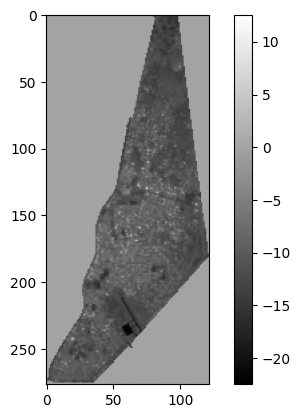

In [ ]:
import rasterio
import matplotlib.pyplot as plt

with rasterio.open("wambera.tif") as src:
    image = src.read(1)
    
    print(image.shape)
    print(image.min(), image.max())
    plt.imshow(image, cmap='gray')
    plt.colorbar()
    plt.show()

In [ ]:

def geodataframe_to_ee(gdf):
    """Convert GeoDataFrame to Earth Engine FeatureCollection"""
    features = []
    for idx, row in gdf.iterrows():
        geom = json.loads(row.geometry.__geo_interface__)
        # Remove properties that aren't serializable
        props = row.drop('geometry').to_dict()
        props = {k: v for k, v in props.items() 
                if isinstance(v, (str, int, float, bool, type(None)))}
        feature = ee.Feature(ee.Geometry(geom), props)
        features.append(feature)
    return ee.FeatureCollection(features)

wards_fc = geodataframe_to_ee(gdf)

TypeError: the JSON object must be str, bytes or bytearray, not dict